# Recommendation Results Analysis

Analyzes LightGCN / SGL / SimGCL results across 5 datasets and exports figures for the final report.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import warnings, os
warnings.filterwarnings('ignore')

FIG_DIR = '../report/figures'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'legend.fontsize': 9, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

MODEL_COLORS = {'LightGCN': '#4878CF', 'SGL': '#6ACC65', 'SimGCL': '#D65F5F'}
MODEL_ORDER  = ['LightGCN', 'SGL', 'SimGCL']
DATASET_LABELS = {
    'ml-1m': 'ML-1M', 'yelp2018': 'Yelp2018',
    'amazon-book': 'Amazon-Book', 'gowalla': 'Gowalla',
    'lastfm_phase2': 'Last.fm-26',
}
DATASET_ORDER = ['ml-1m', 'yelp2018', 'amazon-book', 'gowalla', 'lastfm_phase2']
METRIC_LABELS = {
    'recall@20': 'Recall@20', 'ndcg@20': 'NDCG@20',
    'hr@20': 'HR@20', 'mrr@20': 'MRR@20', 'precision@20': 'Precision@20',
}
METRICS = ['precision@20', 'recall@20', 'ndcg@20', 'hr@20', 'mrr@20']
BENCHMARK_DATASETS = ['ml-1m', 'yelp2018', 'amazon-book', 'gowalla']
DENSITY = {
    'lastfm_phase2': 0.032/100, 'ml-1m': 4.468/100,
    'amazon-book': 0.062/100, 'yelp2018': 0.130/100, 'gowalla': 0.084/100,
}
print('Libraries loaded.')

Libraries loaded.


## 1  Load & Preprocess

In [2]:
raw = pd.read_csv('../results/results.csv').rename(columns={'precision&20': 'precision@20'})
df  = (raw.groupby(['dataset', 'model'])[METRICS].mean().reset_index())
df['dataset'] = pd.Categorical(df['dataset'], categories=DATASET_ORDER, ordered=True)
df['model']   = pd.Categorical(df['model'],   categories=MODEL_ORDER,   ordered=True)
df = df.sort_values(['dataset', 'model']).reset_index(drop=True)
print(df.to_string(index=False))

      dataset    model  precision@20  recall@20  ndcg@20    hr@20   mrr@20
        ml-1m LightGCN      0.007169   0.143377 0.058021 0.143377 0.034844
        ml-1m      SGL      0.006606   0.132119 0.052516 0.132119 0.030890
        ml-1m   SimGCL      0.007329   0.146578 0.056572 0.146578 0.032242
     yelp2018 LightGCN      0.027008   0.060413 0.049110 0.376247 0.102183
     yelp2018      SGL      0.030010   0.067173 0.055211 0.402551 0.114094
     yelp2018   SimGCL      0.032847   0.072786 0.059869 0.428298 0.121985
  amazon-book LightGCN      0.013812   0.033331 0.025691 0.205342 0.050108
  amazon-book      SGL      0.019726   0.047569 0.037556 0.267102 0.070964
  amazon-book   SimGCL      0.020068   0.047888 0.037704 0.271351 0.071263
      gowalla LightGCN      0.052293   0.173365 0.146361 0.576529 0.271025
      gowalla      SGL      0.054611   0.178434 0.150241 0.575424 0.275251
      gowalla   SimGCL      0.056970   0.183148 0.154449 0.584868 0.280364
lastfm_phase2 LightGCN   

## 2  Summary Table

In [3]:
pivot = df.pivot_table(index='dataset', columns='model',
                        values=['recall@20', 'ndcg@20', 'hr@20', 'mrr@20'])
pivot.index = [DATASET_LABELS[d] for d in pivot.index]
display(pivot.round(4))

hr@20                   mrr@20                  ndcg@20  \
model       LightGCN     SGL  SimGCL LightGCN     SGL  SimGCL LightGCN   
ML-1M         0.1434  0.1321  0.1466   0.0348  0.0309  0.0322   0.0580   
Yelp2018      0.3762  0.4026  0.4283   0.1022  0.1141  0.1220   0.0491   
Amazon-Book   0.2053  0.2671  0.2714   0.0501  0.0710  0.0713   0.0257   
Gowalla       0.5765  0.5754  0.5849   0.2710  0.2753  0.2804   0.1464   
Last.fm-26    0.0000  0.0053  0.0044   0.0000  0.0005  0.0004   0.0000   

                            recall@20                  
model           SGL  SimGCL  LightGCN     SGL  SimGCL  
ML-1M        0.0525  0.0566    0.1434  0.1321  0.1466  
Yelp2018     0.0552  0.0599    0.0604  0.0672  0.0728  
Amazon-Book  0.0376  0.0377    0.0333  0.0476  0.0479  
Gowalla      0.1502  0.1544    0.1734  0.1784  0.1831  
Last.fm-26   0.0014  0.0012    0.0000  0.0053  0.0044

## 3  Helper: grouped bar

In [4]:
def grouped_bar(ax, metric, datasets=None, show_legend=True, title=None):
    if datasets is None:
        datasets = DATASET_ORDER
    n_d, n_m, bw = len(datasets), len(MODEL_ORDER), 0.22
    x = np.arange(n_d)
    for i, model in enumerate(MODEL_ORDER):
        vals = []
        for ds in datasets:
            row = df[(df['dataset'] == ds) & (df['model'] == model)]
            vals.append(float(row[metric].iloc[0]) if len(row) else 0.0)
        offset = (i - n_m / 2 + 0.5) * bw
        ax.bar(x + offset, vals, bw, label=model,
               color=MODEL_COLORS[model], edgecolor='white', linewidth=0.5, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels([DATASET_LABELS[d] for d in datasets], rotation=15, ha='right')
    ax.set_ylabel(METRIC_LABELS.get(metric, metric))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    if title: ax.set_title(title, fontweight='bold')
    if show_legend: ax.legend(framealpha=0.85)

## 4  Fig 1 — Recall@20 & NDCG@20 (all datasets)

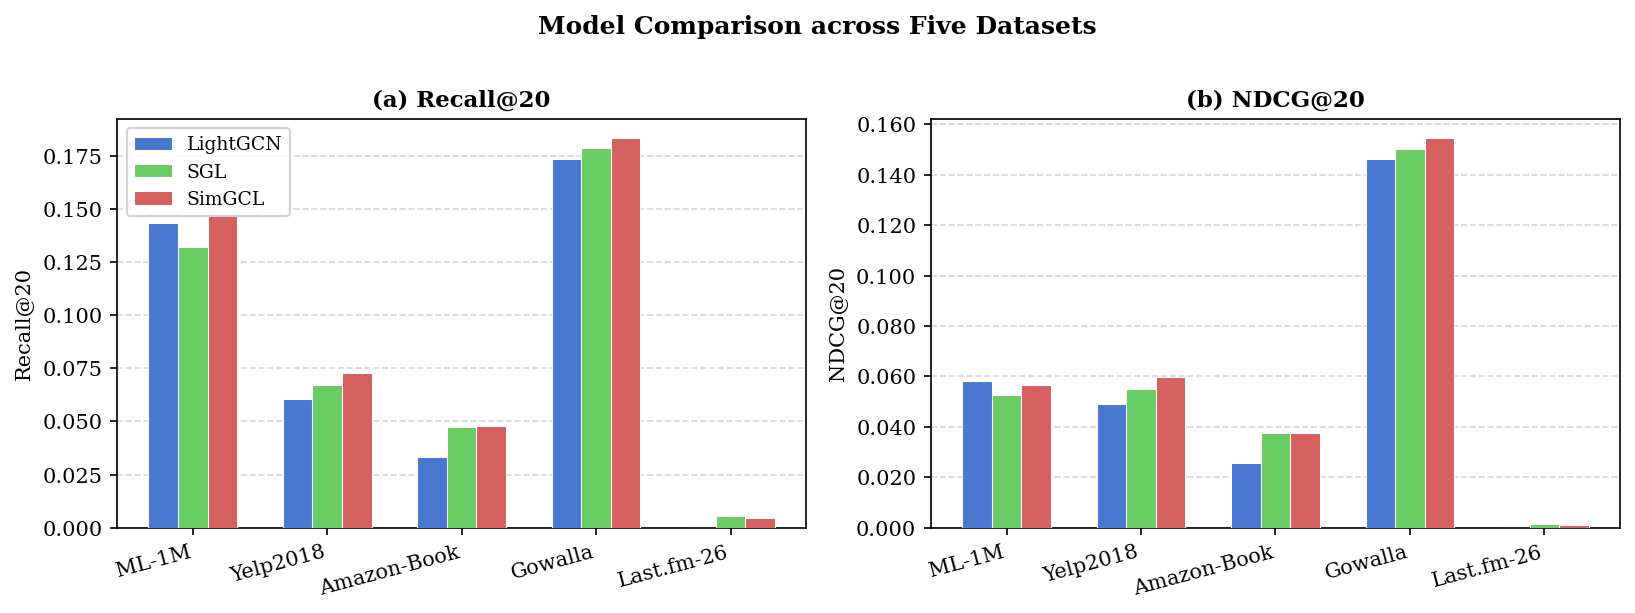

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
grouped_bar(axes[0], 'recall@20', title='(a) Recall@20')
grouped_bar(axes[1], 'ndcg@20',   title='(b) NDCG@20', show_legend=False)
fig.suptitle('Model Comparison across Five Datasets', fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig1_recall_ndcg.pdf')
fig.savefig(f'{FIG_DIR}/fig1_recall_ndcg.png')
plt.show()

## 5  Fig 2 — All Four Metrics (2×2)

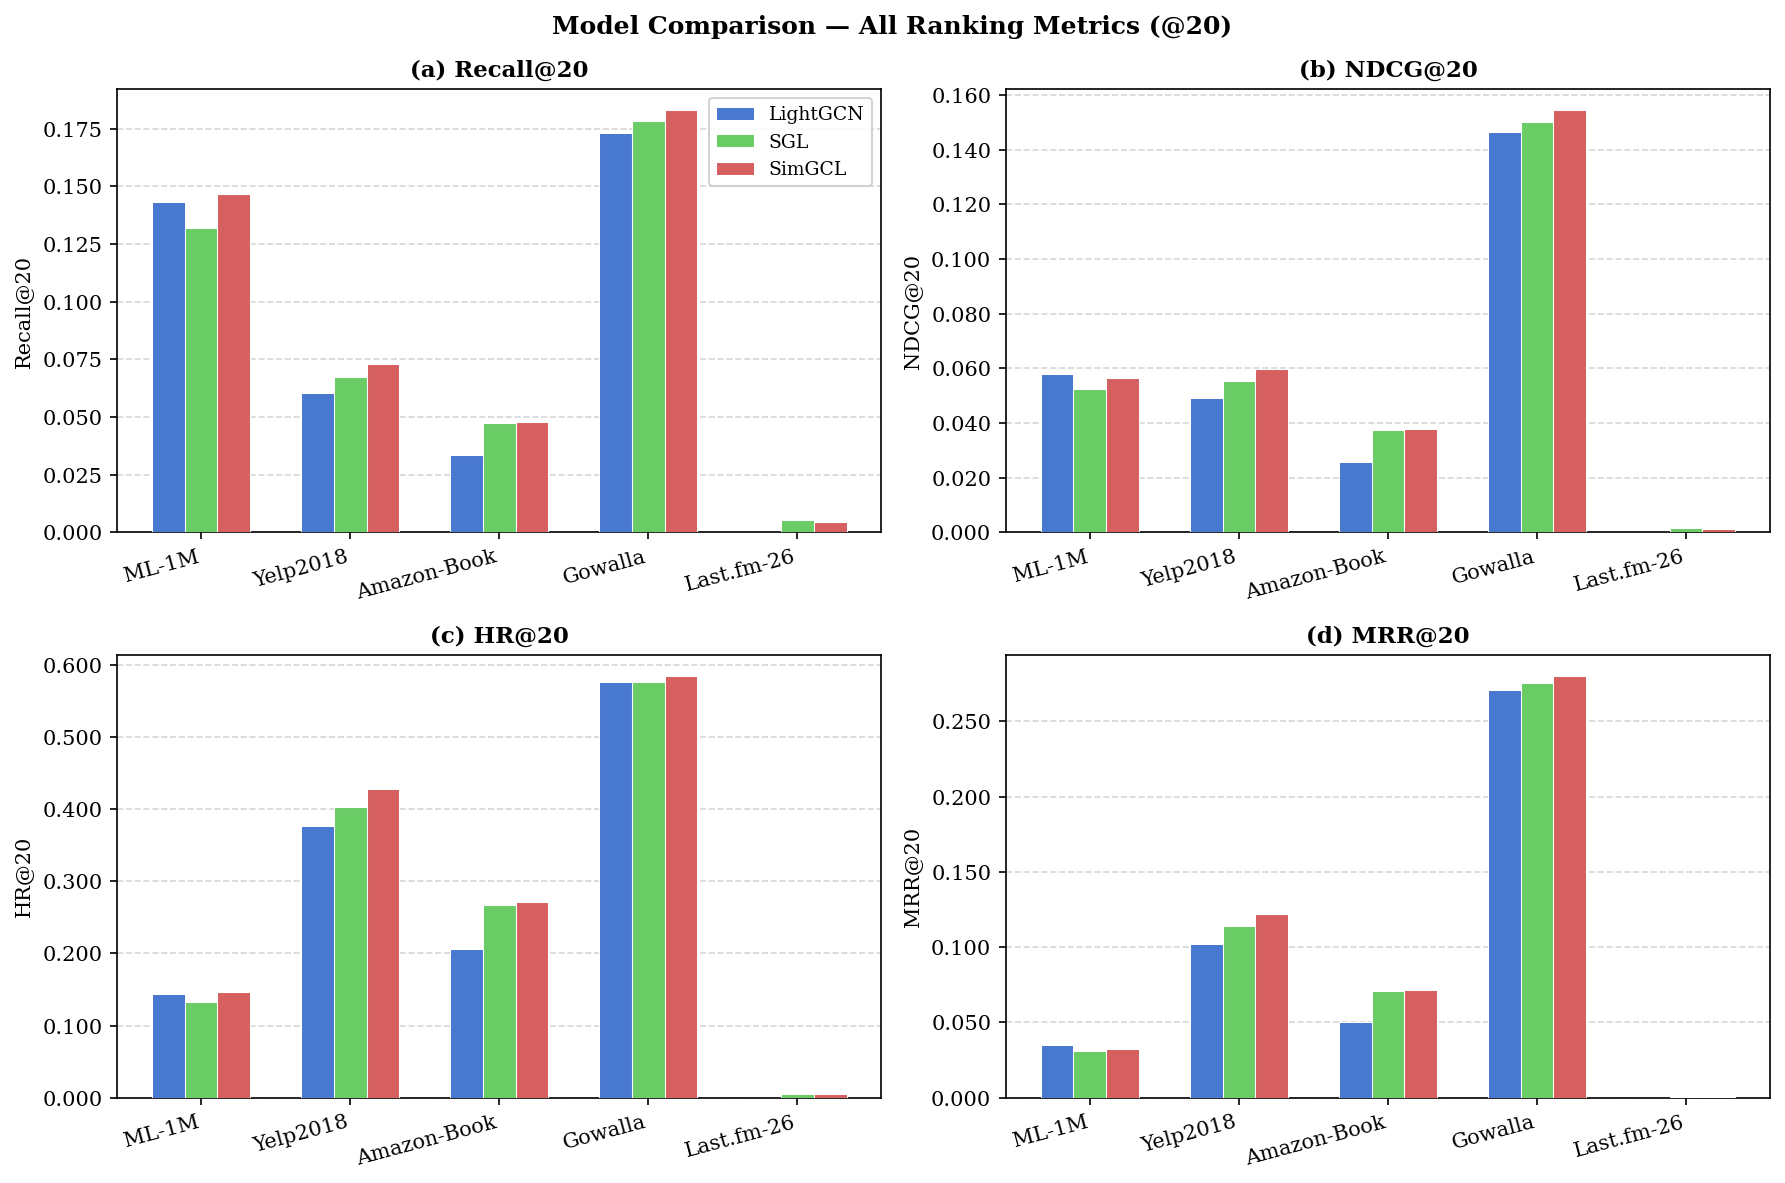

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (m, t) in zip(axes.flat, [
    ('recall@20', '(a) Recall@20'), ('ndcg@20', '(b) NDCG@20'),
    ('hr@20', '(c) HR@20'), ('mrr@20', '(d) MRR@20'),
]):
    grouped_bar(ax, m, title=t, show_legend=(m == 'recall@20'))
fig.suptitle('Model Comparison — All Ranking Metrics (@20)', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig2_all_metrics.pdf')
fig.savefig(f'{FIG_DIR}/fig2_all_metrics.png')
plt.show()

## 6  Fig 3 — Heatmap: Relative Improvement over LightGCN

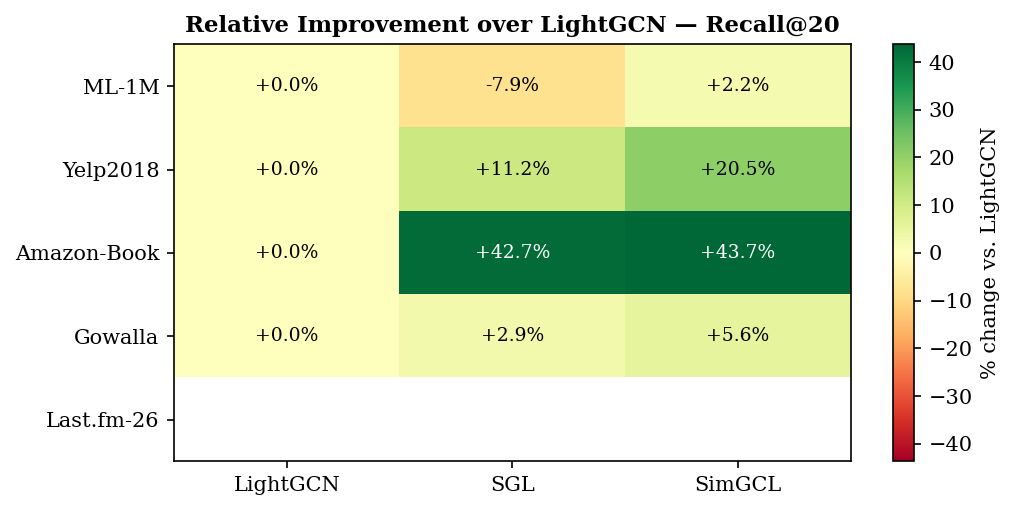

Saved fig3_improvement_recall_20


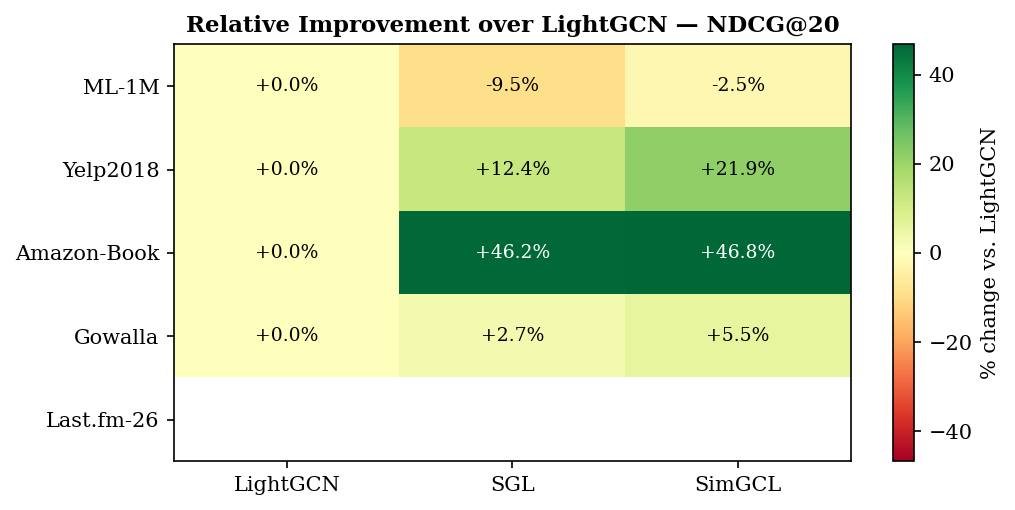

Saved fig3_improvement_ndcg_20


In [7]:
for metric_key, metric_label in [('recall@20', 'Recall@20'), ('ndcg@20', 'NDCG@20')]:
    rows = []
    for ds in DATASET_ORDER:
        base_row = df[(df['dataset'] == ds) & (df['model'] == 'LightGCN')]
        base_val = float(base_row[metric_key].iloc[0]) if len(base_row) else np.nan
        row = {'dataset': DATASET_LABELS[ds]}
        for model in MODEL_ORDER:
            m_row = df[(df['dataset'] == ds) & (df['model'] == model)]
            m_val = float(m_row[metric_key].iloc[0]) if len(m_row) else np.nan
            row[model] = (m_val - base_val) / base_val * 100 if (base_val and base_val > 0) else np.nan
        rows.append(row)
    imp_df = pd.DataFrame(rows).set_index('dataset')
    data = imp_df.values.astype(float)
    vmax = np.nanmax(np.abs(data))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    im = ax.imshow(data, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(MODEL_ORDER))); ax.set_xticklabels(MODEL_ORDER)
    ax.set_yticks(range(len(DATASET_ORDER)))
    ax.set_yticklabels([DATASET_LABELS[d] for d in DATASET_ORDER])
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]
            txt = f'{val:+.1f}%' if not np.isnan(val) else 'N/A'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                    color='black' if abs(val) < vmax * 0.6 else 'white')
    plt.colorbar(im, ax=ax, label='% change vs. LightGCN')
    ax.set_title(f'Relative Improvement over LightGCN — {metric_label}', fontweight='bold')
    fig.tight_layout()
    fname = f'fig3_improvement_{metric_key.replace("@","_")}'
    fig.savefig(f'{FIG_DIR}/{fname}.pdf'); fig.savefig(f'{FIG_DIR}/{fname}.png')
    plt.show()
    print(f'Saved {fname}')

## 7  Fig 4 — Benchmark Only (exclude Last.fm)

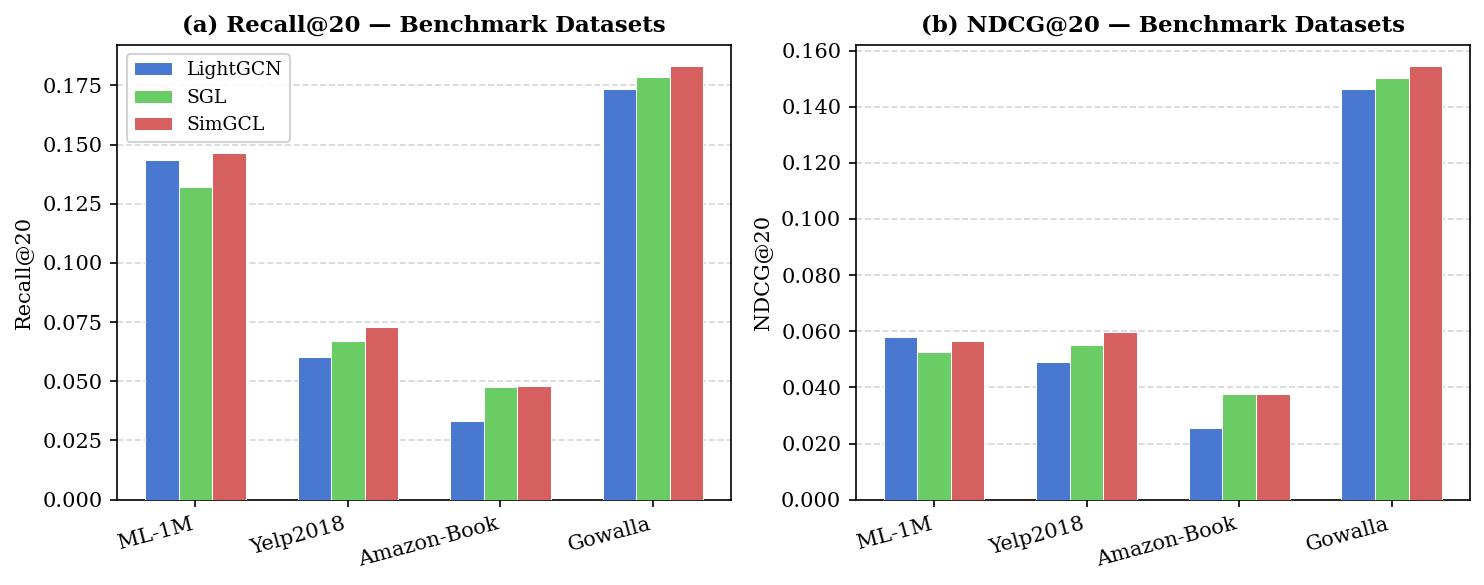

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
grouped_bar(axes[0], 'recall@20', datasets=BENCHMARK_DATASETS,
            title='(a) Recall@20 — Benchmark Datasets')
grouped_bar(axes[1], 'ndcg@20', datasets=BENCHMARK_DATASETS,
            title='(b) NDCG@20 — Benchmark Datasets', show_legend=False)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig4_benchmark.pdf')
fig.savefig(f'{FIG_DIR}/fig4_benchmark.png')
plt.show()

## 8  Fig 5 — Last.fm-26 Zoomed

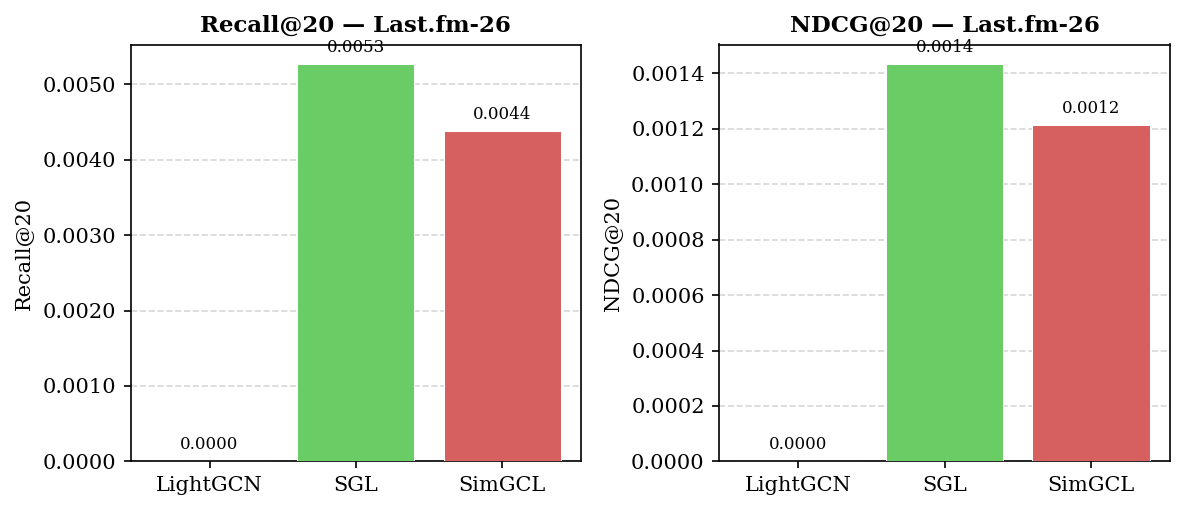

In [9]:
lastfm_df = df[df['dataset'] == 'lastfm_phase2'].copy()
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, metric in zip(axes, ['recall@20', 'ndcg@20']):
    vals = [float(lastfm_df[lastfm_df['model'] == m][metric].iloc[0])
             if len(lastfm_df[lastfm_df['model'] == m]) else 0.0
             for m in MODEL_ORDER]
    bars = ax.bar(MODEL_ORDER, vals, color=[MODEL_COLORS[m] for m in MODEL_ORDER],
                  edgecolor='white', linewidth=0.5, zorder=3)
    ax.set_ylabel(METRIC_LABELS[metric])
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.set_title(f'{METRIC_LABELS[metric]} — Last.fm-26', fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig5_lastfm.pdf'); fig.savefig(f'{FIG_DIR}/fig5_lastfm.png')
plt.show()

## 9  Fig 6 — Radar Chart

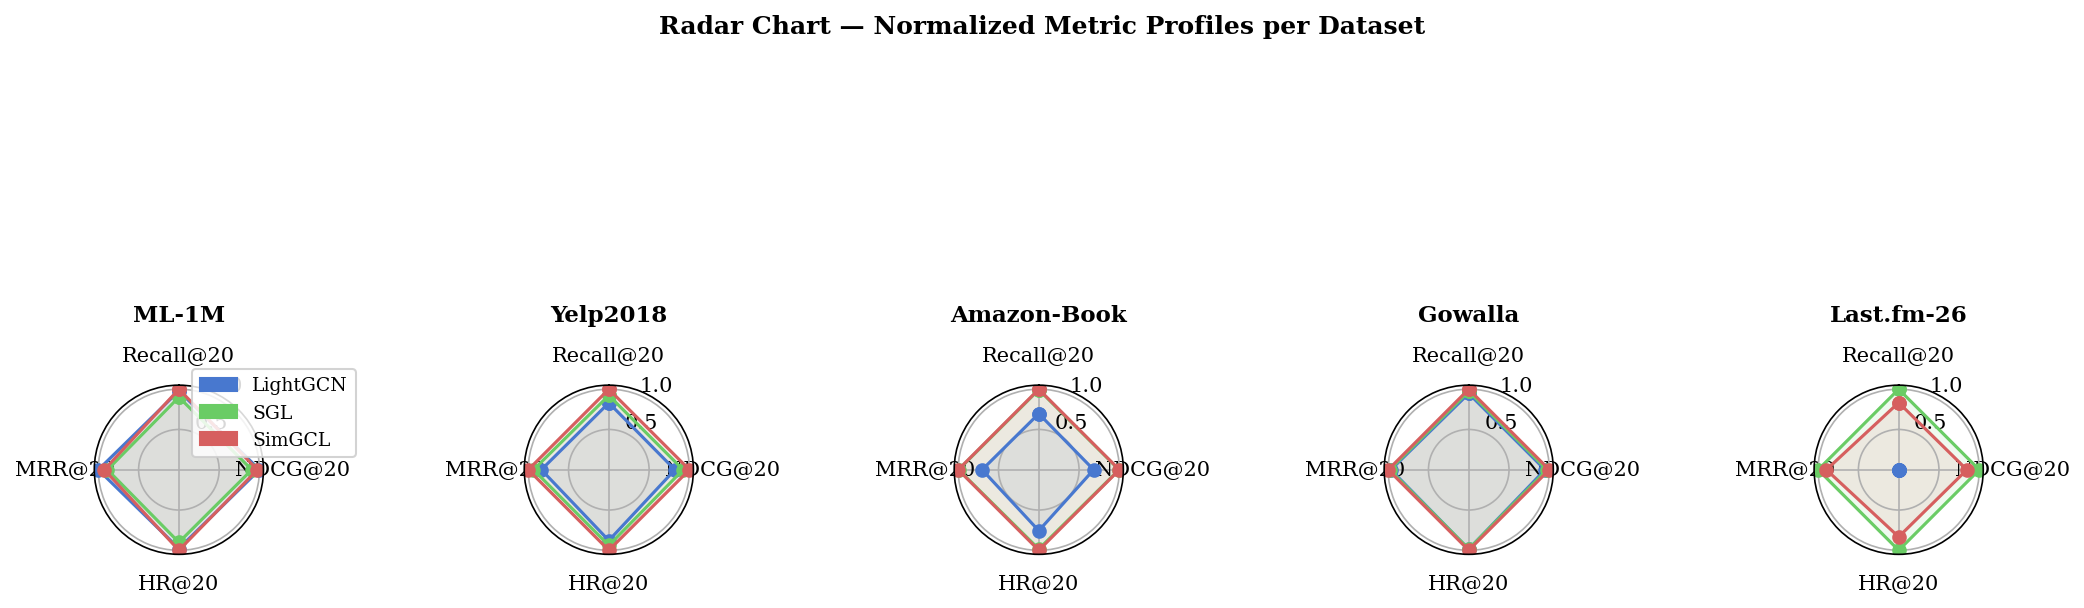

In [10]:
RADAR_METRICS = ['recall@20', 'ndcg@20', 'hr@20', 'mrr@20']
RADAR_LABELS  = ['Recall@20', 'NDCG@20', 'HR@20', 'MRR@20']

def radar_chart(ax, dataset):
    N = len(RADAR_METRICS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), RADAR_LABELS)
    all_vals = {m: [] for m in RADAR_METRICS}
    for model in MODEL_ORDER:
        row = df[(df['dataset'] == dataset) & (df['model'] == model)]
        if len(row):
            for m in RADAR_METRICS: all_vals[m].append(float(row[m].iloc[0]))
    maxes = {m: max(v) if max(v) > 0 else 1.0 for m, v in all_vals.items()}
    for model in MODEL_ORDER:
        row = df[(df['dataset'] == dataset) & (df['model'] == model)]
        if not len(row): continue
        vals = [float(row[m].iloc[0]) / maxes[m] for m in RADAR_METRICS] + \
               [float(row[RADAR_METRICS[0]].iloc[0]) / maxes[RADAR_METRICS[0]]]
        ax.plot(angles, vals, 'o-', linewidth=1.5, label=model, color=MODEL_COLORS[model])
        ax.fill(angles, vals, alpha=0.1, color=MODEL_COLORS[model])
    ax.set_ylim(0, 1.05)
    ax.set_title(DATASET_LABELS[dataset], fontweight='bold', pad=12)

fig = plt.figure(figsize=(14, 6))
for idx, ds in enumerate(DATASET_ORDER):
    ax = fig.add_subplot(1, 5, idx + 1, polar=True)
    radar_chart(ax, ds)
    if idx == 0:
        handles = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MODEL_ORDER]
        ax.legend(handles=handles, loc='upper right',
                  bbox_to_anchor=(1.6, 1.15), framealpha=0.85)
fig.suptitle('Radar Chart — Normalized Metric Profiles per Dataset',
             fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig6_radar.pdf'); fig.savefig(f'{FIG_DIR}/fig6_radar.png')
plt.show()

## 10  Fig 7 — Run Stability (error bars)

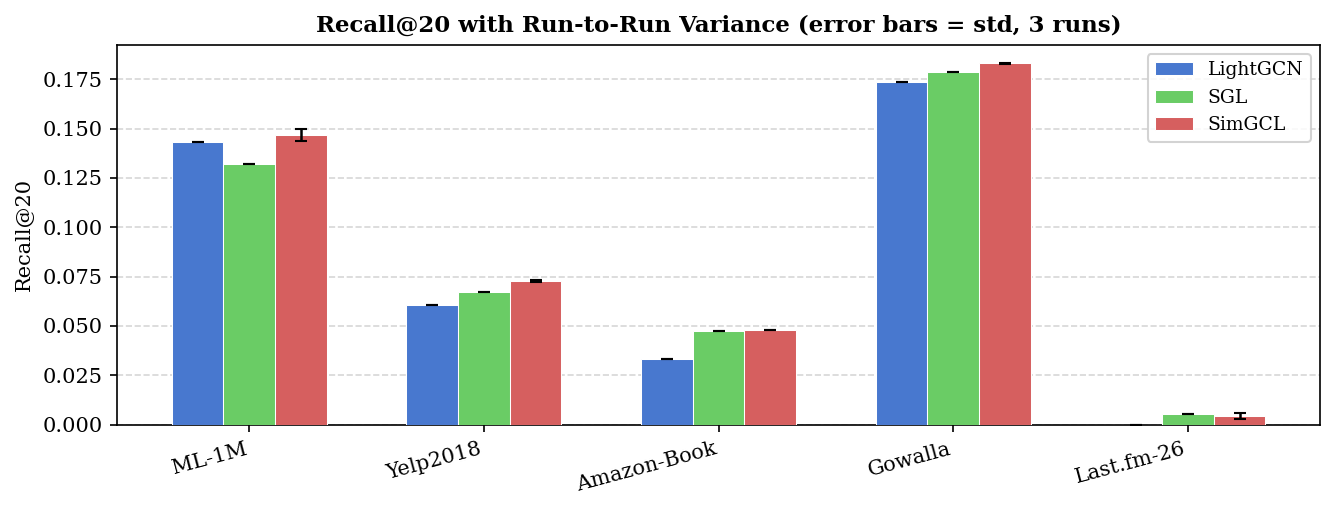

In [11]:
raw2 = pd.read_csv('../results/results.csv').rename(columns={'precision&20': 'precision@20'})
std_df = raw2.groupby(['dataset', 'model'])[METRICS].std().reset_index()

fig, ax = plt.subplots(figsize=(9, 3.5))
metric = 'recall@20'
bw = 0.22
x = np.arange(len(DATASET_ORDER))
for i, model in enumerate(MODEL_ORDER):
    means, stds = [], []
    for ds in DATASET_ORDER:
        m_row = df[(df['dataset'] == ds) & (df['model'] == model)]
        s_row = std_df[(std_df['dataset'] == ds) & (std_df['model'] == model)]
        means.append(float(m_row[metric].iloc[0]) if len(m_row) else 0.0)
        stds.append(float(s_row[metric].iloc[0]) if len(s_row) else 0.0)
    offset = (i - len(MODEL_ORDER) / 2 + 0.5) * bw
    ax.bar(x + offset, means, bw, label=model, color=MODEL_COLORS[model],
           edgecolor='white', linewidth=0.5, zorder=3,
           yerr=stds, capsize=3, error_kw={'linewidth': 1.2})
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASET_ORDER], rotation=15, ha='right')
ax.set_ylabel('Recall@20')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True); ax.legend(framealpha=0.85)
ax.set_title('Recall@20 with Run-to-Run Variance (error bars = std, 3 runs)', fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig7_stability.pdf'); fig.savefig(f'{FIG_DIR}/fig7_stability.png')
plt.show()

## 11  Fig 8 — Dataset Density vs. Contrastive Gain

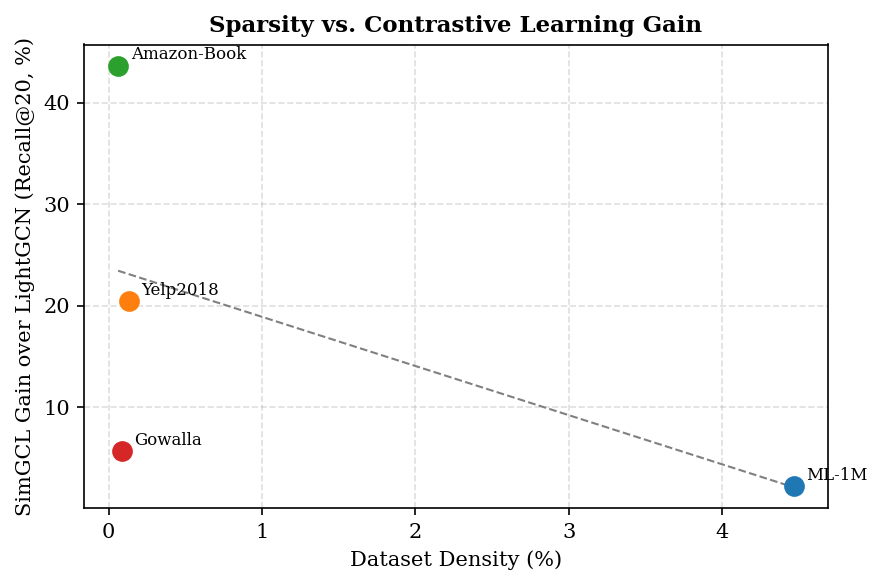

In [12]:
records = []
for ds in DATASET_ORDER:
    base   = df[(df['dataset'] == ds) & (df['model'] == 'LightGCN')]['recall@20']
    simgcl = df[(df['dataset'] == ds) & (df['model'] == 'SimGCL')]['recall@20']
    if len(base) and len(simgcl) and float(base.iloc[0]) > 0:
        gain = (float(simgcl.iloc[0]) - float(base.iloc[0])) / float(base.iloc[0]) * 100
        records.append({'dataset': DATASET_LABELS[ds],
                        'density': DENSITY[ds] * 100, 'gain': gain})
sc_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(6, 4))
for _, row in sc_df.iterrows():
    ax.scatter(row['density'], row['gain'], s=80, zorder=5)
    ax.annotate(row['dataset'], (row['density'], row['gain']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
if len(sc_df) >= 2:
    z = np.polyfit(sc_df['density'], sc_df['gain'], 1)
    xs = np.linspace(sc_df['density'].min(), sc_df['density'].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), '--', color='gray', linewidth=1, label='trend')
ax.set_xlabel('Dataset Density (%)')
ax.set_ylabel('SimGCL Gain over LightGCN (Recall@20, %)')
ax.set_title('Sparsity vs. Contrastive Learning Gain', fontweight='bold')
ax.grid(linestyle='--', alpha=0.4)
fig.tight_layout()
fig.savefig(f'{FIG_DIR}/fig8_density_gain.pdf'); fig.savefig(f'{FIG_DIR}/fig8_density_gain.png')
plt.show()

## 13  Key Findings

In [13]:
print('=== KEY FINDINGS ===')
print()
print('Best model per dataset (Recall@20):')
for ds in DATASET_ORDER:
    sub  = df[df['dataset'] == ds]
    best = sub.loc[sub['recall@20'].idxmax()]
    print(f'  {DATASET_LABELS[ds]:14s}: {best["model"]:10s}  {best["recall@20"]:.4f}')

print()
print('SimGCL vs LightGCN relative gain (Recall@20, benchmark datasets):')
for ds in BENCHMARK_DATASETS:
    b = float(df[(df['dataset']==ds)&(df['model']=='LightGCN')]['recall@20'].iloc[0])
    t = float(df[(df['dataset']==ds)&(df['model']=='SimGCL')]['recall@20'].iloc[0])
    print(f'  {DATASET_LABELS[ds]:14s}: +{(t-b)/b*100:.1f}%')

print()
print('SGL vs LightGCN relative gain (Recall@20, benchmark datasets):')
for ds in BENCHMARK_DATASETS:
    b = float(df[(df['dataset']==ds)&(df['model']=='LightGCN')]['recall@20'].iloc[0])
    s = float(df[(df['dataset']==ds)&(df['model']=='SGL')]['recall@20'].iloc[0])
    print(f'  {DATASET_LABELS[ds]:14s}: +{(s-b)/b*100:.1f}%')

print()
print('Last.fm-26: LightGCN = 0 on all metrics.')
print('SGL & SimGCL non-zero — contrastive learning slightly alleviates extreme sparsity.')

=== KEY FINDINGS ===

Best model per dataset (Recall@20):
  ML-1M         : SimGCL      0.1466
  Yelp2018      : SimGCL      0.0728
  Amazon-Book   : SimGCL      0.0479
  Gowalla       : SimGCL      0.1831
  Last.fm-26    : SGL         0.0053

SimGCL vs LightGCN relative gain (Recall@20, benchmark datasets):
  ML-1M         : +2.2%
  Yelp2018      : +20.5%
  Amazon-Book   : +43.7%
  Gowalla       : +5.6%

SGL vs LightGCN relative gain (Recall@20, benchmark datasets):
  ML-1M         : +-7.9%
  Yelp2018      : +11.2%
  Amazon-Book   : +42.7%
  Gowalla       : +2.9%

Last.fm-26: LightGCN = 0 on all metrics.
SGL & SimGCL non-zero — contrastive learning slightly alleviates extreme sparsity.
